# Best Model Analysis

This notebook does the following analyses on the best model found by Optuna:
- Plots: t-SNE and confusion matrix
- EDL classifiers comparison
- Decision tree classifier study

## Setup

In [1]:
from collections.abc import Callable
from pathlib import Path

import dtreeviz
import matplotlib.pyplot as plt
import numpy as np
import optuna
import scienceplots  # noqa: F401
import torch
from edl_losses.edl import edl_inference
from edl_losses.gen import gen_inference
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier

from csi_vae.jobs import JobSettings, dataset, fusion, vae
from csi_vae.jobs.job import make_dataloader
from csi_vae.studies import get_best_model, read_studies

plt.style.use(["science", "no-latex", "bright"])
plt.rcParams.update({"figure.dpi": 300})

settings = JobSettings()

OUT_DIR = Path("../out")
FUSION_LAUNCH_DIR = OUT_DIR / "fusion"
PLOTS_DIR = OUT_DIR / "plots"
EDL_DIR = OUT_DIR / "edl"
WEIGHTS_DIR = Path("../weights")
OOD_DATASET = Path("../dataset/S1b.h5")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ACTIVITIES = ["Walk", "Run", "Jump", "Sit", "Empty", "Stand", "Waving", "Clap", "Lay down", "Wipe", "Squat", "Stretch"]

PLOTS_DIR.mkdir(exist_ok=True)

/mnt/servicesdata/lcotti/csi-vae/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


### Load Best Model

To find the best model we first take the trial with the highest mean accuracy across the ten seeds. Then we take the seed with the highest accuracy.

In [2]:
studies = read_studies(FUSION_LAUNCH_DIR)
best_model = get_best_model(studies)
best_model

StudyResult(n_gaussians=2, trial_number=77, trial_value=0.965625, seed=347227206, best_seed_accuracy=0.98125, accuracies_per_seed={'769622246': 0.96875, '420148083': 0.9666666666666667, '1546791838': 0.9541666666666667, '1062011930': 0.9729166666666667, '347227206': 0.98125, '528409543': 0.9708333333333333, '860377586': 0.9625, '1195442376': 0.9416666666666667, '844665796': 0.9645833333333333, '528653765': 0.9583333333333334}, params={'batch_size_exp': 6, 'conv_layers_spec': 2, 'fusion_dropout': 0.0, 'kl_max': 17.84387815016845, 'lr': 0.0032226209133048383, 'n_fusion_layers': 2})

In [3]:
gaussians = [
    vae.SingleAntenna(
        settings.window_size,
        settings.n_subcarriers,
        best_model.n_gaussians,
        vae.CONV_SPECS[best_model.params["conv_layers_spec"]],
    ).to(DEVICE)
    for _ in range(settings.n_antennas)
]
delayed_fusion = fusion.Delayed(
    gaussians,
    best_model.n_gaussians,
    settings.n_activities,
    best_model.params["n_fusion_layers"],
    best_model.params["fusion_dropout"],
).to(DEVICE)

model_path = (
    WEIGHTS_DIR
    / "fusion"
    / f"l{best_model.n_gaussians}"
    / f"t{best_model.trial_number}"
    / f"s{best_model.seed}"
    / "delayed_fusion.pt"
)
delayed_fusion.load_state_dict(torch.load(model_path))

<All keys matched successfully>

### Load Dataset

In [4]:
batch_size = 2**best_model.params["batch_size_exp"]

train_ds, val_ds, test_ds = dataset.load(
    dataset_path=Path("../") / settings.dataset_path,
    window_size=settings.window_size,
    n_activities=settings.n_activities,
    stride=settings.stride,
)
full_ds = torch.utils.data.ConcatDataset([train_ds, val_ds, test_ds])

train_dl = make_dataloader(train_ds, batch_size=batch_size, shuffle=True, seed=best_model.seed)
val_dl = make_dataloader(val_ds, batch_size=batch_size, shuffle=False, seed=best_model.seed)
test_dl = make_dataloader(test_ds, batch_size=batch_size, shuffle=False, seed=best_model.seed)
full_dl = make_dataloader(full_ds, batch_size=batch_size, shuffle=False, seed=best_model.seed)

## Best Model Plots

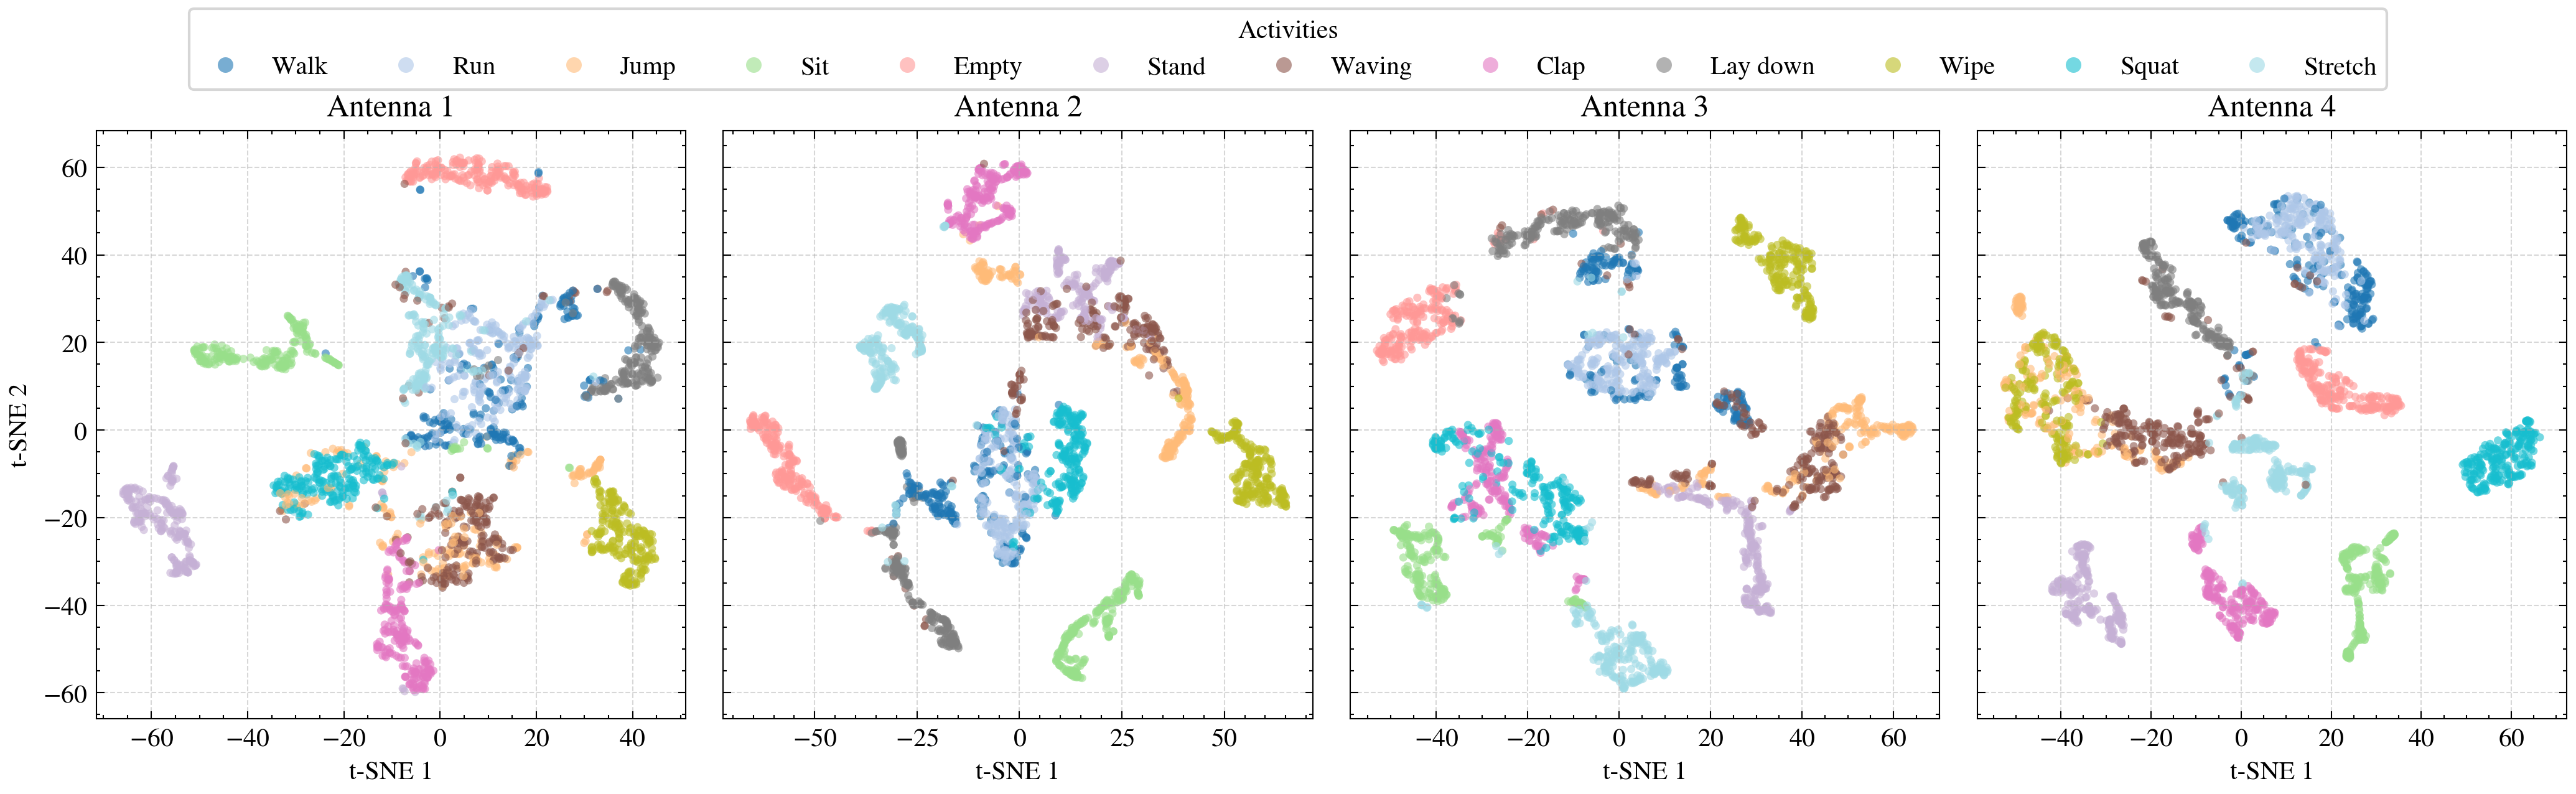

In [ ]:
def plot_tsne(
    gaussians: list[vae.SingleAntenna],
    dataloader: torch.utils.data.DataLoader,
    activities: list[str],
    seed: int,
    out_dir: Path,
    device: torch.device,
) -> None:
    """Plot t-SNE of the latent space for each antenna's Gaussian encoder.

    Arguments:
        gaussians: List of Gaussian encoders, one per antenna.
        dataloader: DataLoader for the dataset to extract latents from.
        activities: List of activity names.
        seed: Random seed for t-SNE reproducibility.
        out_dir: Directory to save the plot.
        device: The device to run the Gaussian encoders on.

    """
    antennas_latents, antennas_labels = [], []

    for antenna_idx, gaussian in enumerate(gaussians):
        antenna_latents, antenna_labels = [], []

        gaussian.eval().to(device)
        for x, y in dataloader:
            with torch.no_grad():
                x_antenna = x[:, antenna_idx].to(device, dtype=torch.float32)
                mu, logvar = gaussian.encode(x_antenna)

                antenna_latents.append(torch.cat([mu, logvar], dim=1).cpu().numpy())
                antenna_labels.append(y.numpy())

        antennas_latents.append(np.concatenate(antenna_latents))
        antennas_labels.append(np.concatenate(antenna_labels))

    fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
    axes = axes.ravel()

    last_scatter = None

    for antenna_idx, (latents, labels) in enumerate(zip(antennas_latents, antennas_labels, strict=True)):
        tsne = TSNE(
            n_components=2,
            random_state=seed,
            perplexity=30,
        ).fit_transform(latents)

        ax = axes[antenna_idx]
        last_scatter = ax.scatter(
            tsne[:, 0],
            tsne[:, 1],
            c=labels,
            cmap="tab20",
            alpha=0.6,
            edgecolor="w",
            s=10,
            linewidths=0,
            vmin=0,
            vmax=len(activities) - 1,
        )

        ax.set_title(f"Antenna {antenna_idx + 1}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2" if antenna_idx == 0 else "")
        ax.grid(True, linestyle="--", alpha=0.5)

    handles, _ = last_scatter.legend_elements(prop="colors", num=len(activities))  # pyright: ignore[reportOptionalMemberAccess]
    fig.legend(
        handles,
        activities,
        title="Activities",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.08),
        ncol=len(activities),
        frameon=True,
        borderaxespad=0.1,
    )

    plt.tight_layout()
    plt.savefig(out_dir / "best_tsne_gaussians.pdf", bbox_inches="tight")
    plt.show()


plot_tsne(gaussians, full_dl, ACTIVITIES, best_model.seed, PLOTS_DIR, DEVICE)

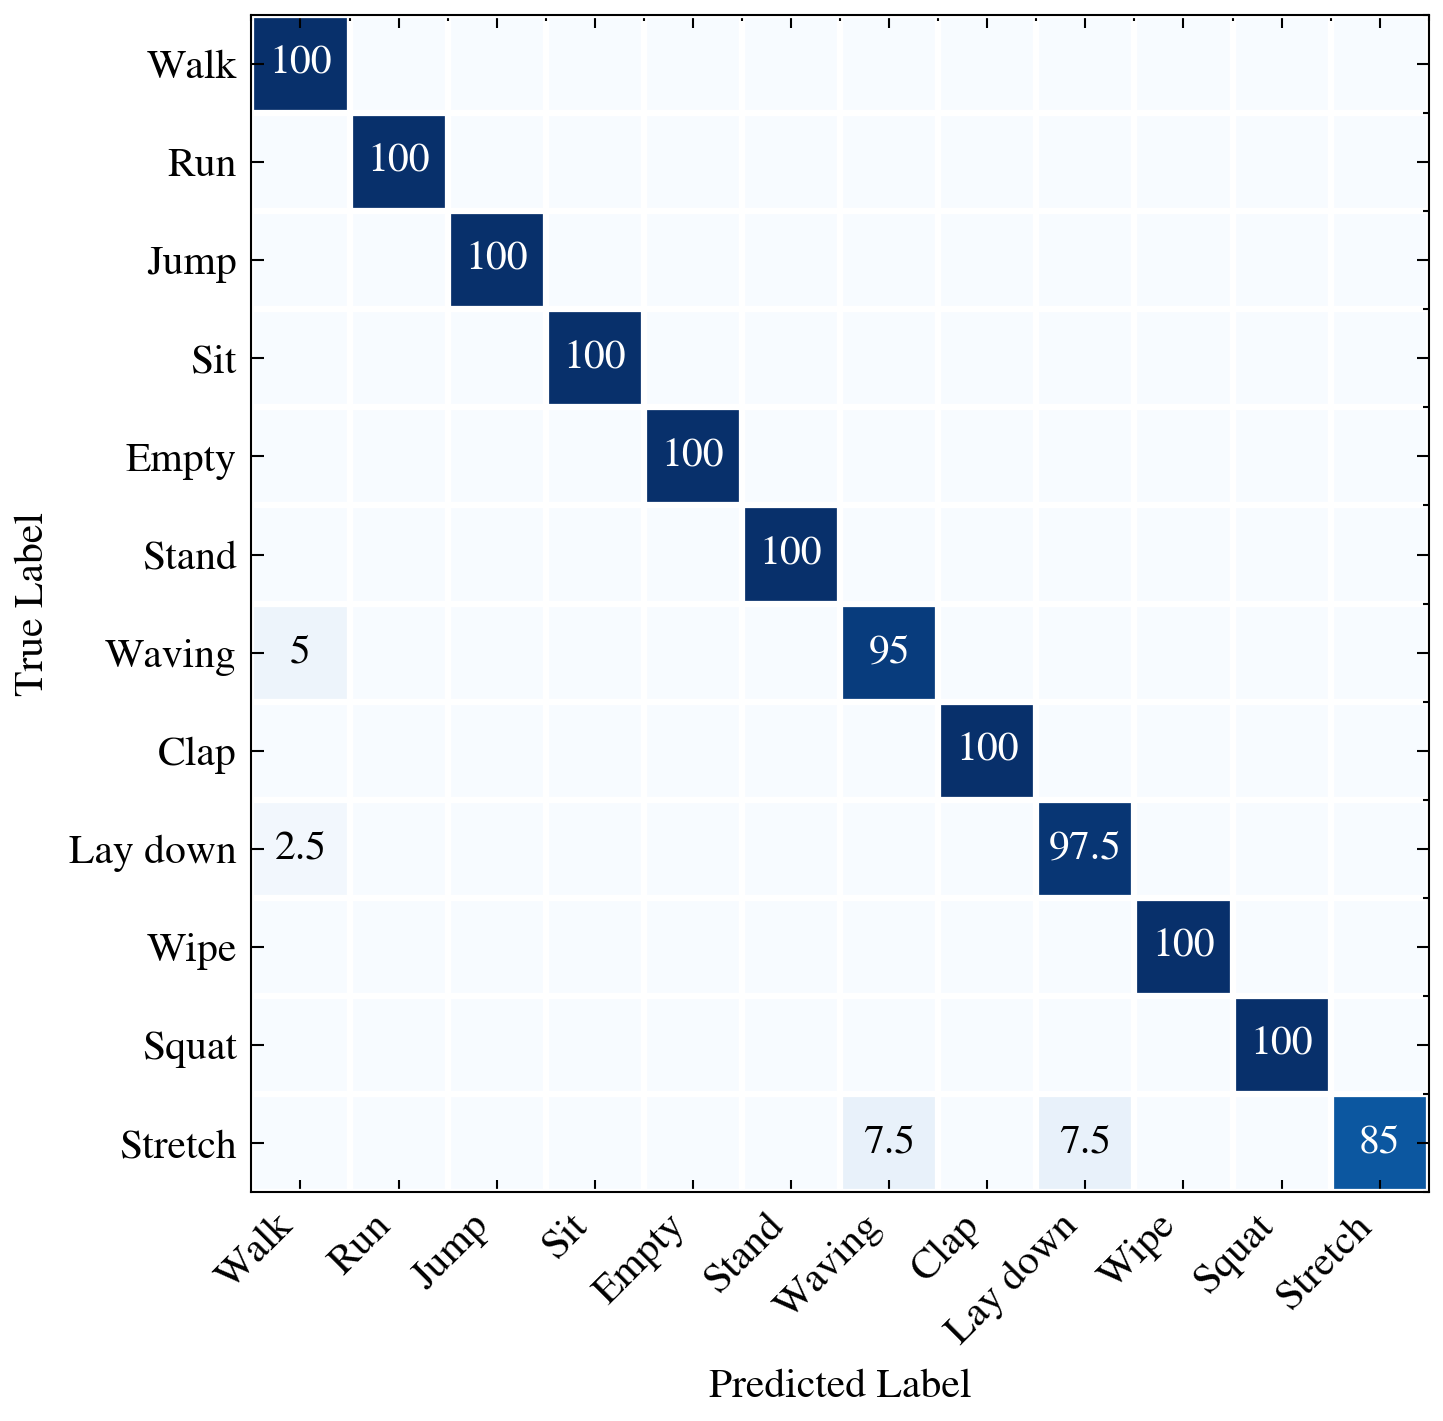

In [6]:
def plot_confusion_matrix(
    model: fusion.Delayed,
    dataloader: torch.utils.data.DataLoader,
    activities: list[str],
    device: torch.device,
) -> None:
    """Plot confusion matrix of the model's predictions on the given dataloader.

    Arguments:
        model: The trained fusion.Delayed model to evaluate.
        dataloader: DataLoader for the dataset to evaluate on.
        activities: List of activity names.
        device: The device to run the model on.

    """
    y_preds, y_trues = [], []
    for x, y in dataloader:
        with torch.no_grad():
            y_pred = model(x.to(device, dtype=torch.float32))
            y_preds.append(y_pred.cpu().numpy())
            y_trues.append(y.numpy())

    cm = confusion_matrix(
        np.concatenate(y_trues),
        np.concatenate(y_preds).argmax(axis=1),
    )

    plt.figure(figsize=(5, 5))
    # Normalize by row (True Labels) to see percentages
    matrix_perc = cm.astype("float") / (cm.sum(axis=1)[:, np.newaxis] + 1e-12)

    plt.imshow(matrix_perc, cmap="Blues")

    thresh = matrix_perc.max() / 2
    for i in range(len(activities)):
        for j in range(len(activities)):
            # Skip zero counts for better readability
            if cm[i, j] == 0:
                continue

            color = "white" if matrix_perc[i, j] > thresh else "black"
            text = f"{matrix_perc[i, j] * 100:.1f}".rstrip("0").rstrip(".")
            plt.text(j, i, text, ha="center", va="center", color=color)

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha="right", ticks=np.arange(len(activities)), labels=activities)
    plt.yticks(rotation=0, ticks=np.arange(len(activities)), labels=activities)

    ax = plt.gca()
    ax.set_xticks(np.arange(-0.5, len(activities)), minor=True)
    ax.set_yticks(np.arange(-0.5, len(activities)), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "best_confusion_matrix_gaussians.pdf", bbox_inches="tight")
    plt.show()


plot_confusion_matrix(delayed_fusion, test_dl, ACTIVITIES, DEVICE)

## EDL

In [7]:
ood_train_ds, ood_val_ds, ood_test_ds = dataset.load(
    dataset_path=OOD_DATASET,
    window_size=settings.window_size,
    n_activities=settings.n_activities,
    stride=settings.stride,
)
ood_ds = torch.utils.data.ConcatDataset([ood_train_ds, ood_val_ds, ood_test_ds])
ood_dl = make_dataloader(ood_ds, batch_size=batch_size, shuffle=False, seed=best_model.seed)

In [8]:
edl_study = optuna.load_study(
    study_name="edl",
    storage=f"sqlite:///{EDL_DIR}/edl.sqlite",
)

edl_fusion = fusion.Delayed(
    gaussians,
    best_model.n_gaussians,
    settings.n_activities,
    best_model.params["n_fusion_layers"],
    best_model.params["fusion_dropout"],
)
edl_fusion.to(DEVICE)
edl_fusion.load_state_dict(torch.load(WEIGHTS_DIR / "edl" / f"t{edl_study.best_trial.number}" / "delayed_fusion.pt"))

FileNotFoundError: [Errno 2] No such file or directory: '../weights/edl/t95/delayed_fusion.pt'

In [ ]:
gen_study = optuna.load_study(
    study_name="gen",
    storage=f"sqlite:///{EDL_DIR}/gen.sqlite",
)

gen_fusion = fusion.Delayed(
    gaussians,
    best_model.n_gaussians,
    settings.n_activities,
    best_model.params["n_fusion_layers"],
    best_model.params["fusion_dropout"],
).to(DEVICE)
gen_fusion.to(DEVICE)
gen_fusion.load_state_dict(torch.load(WEIGHTS_DIR / "gen" / f"t{gen_study.best_trial.number}" / "delayed_fusion.pt"))

<All keys matched successfully>

In [ ]:
edl_study.best_trial.params

{'should_anneal': False, 'beta': 0.20376016612839062}

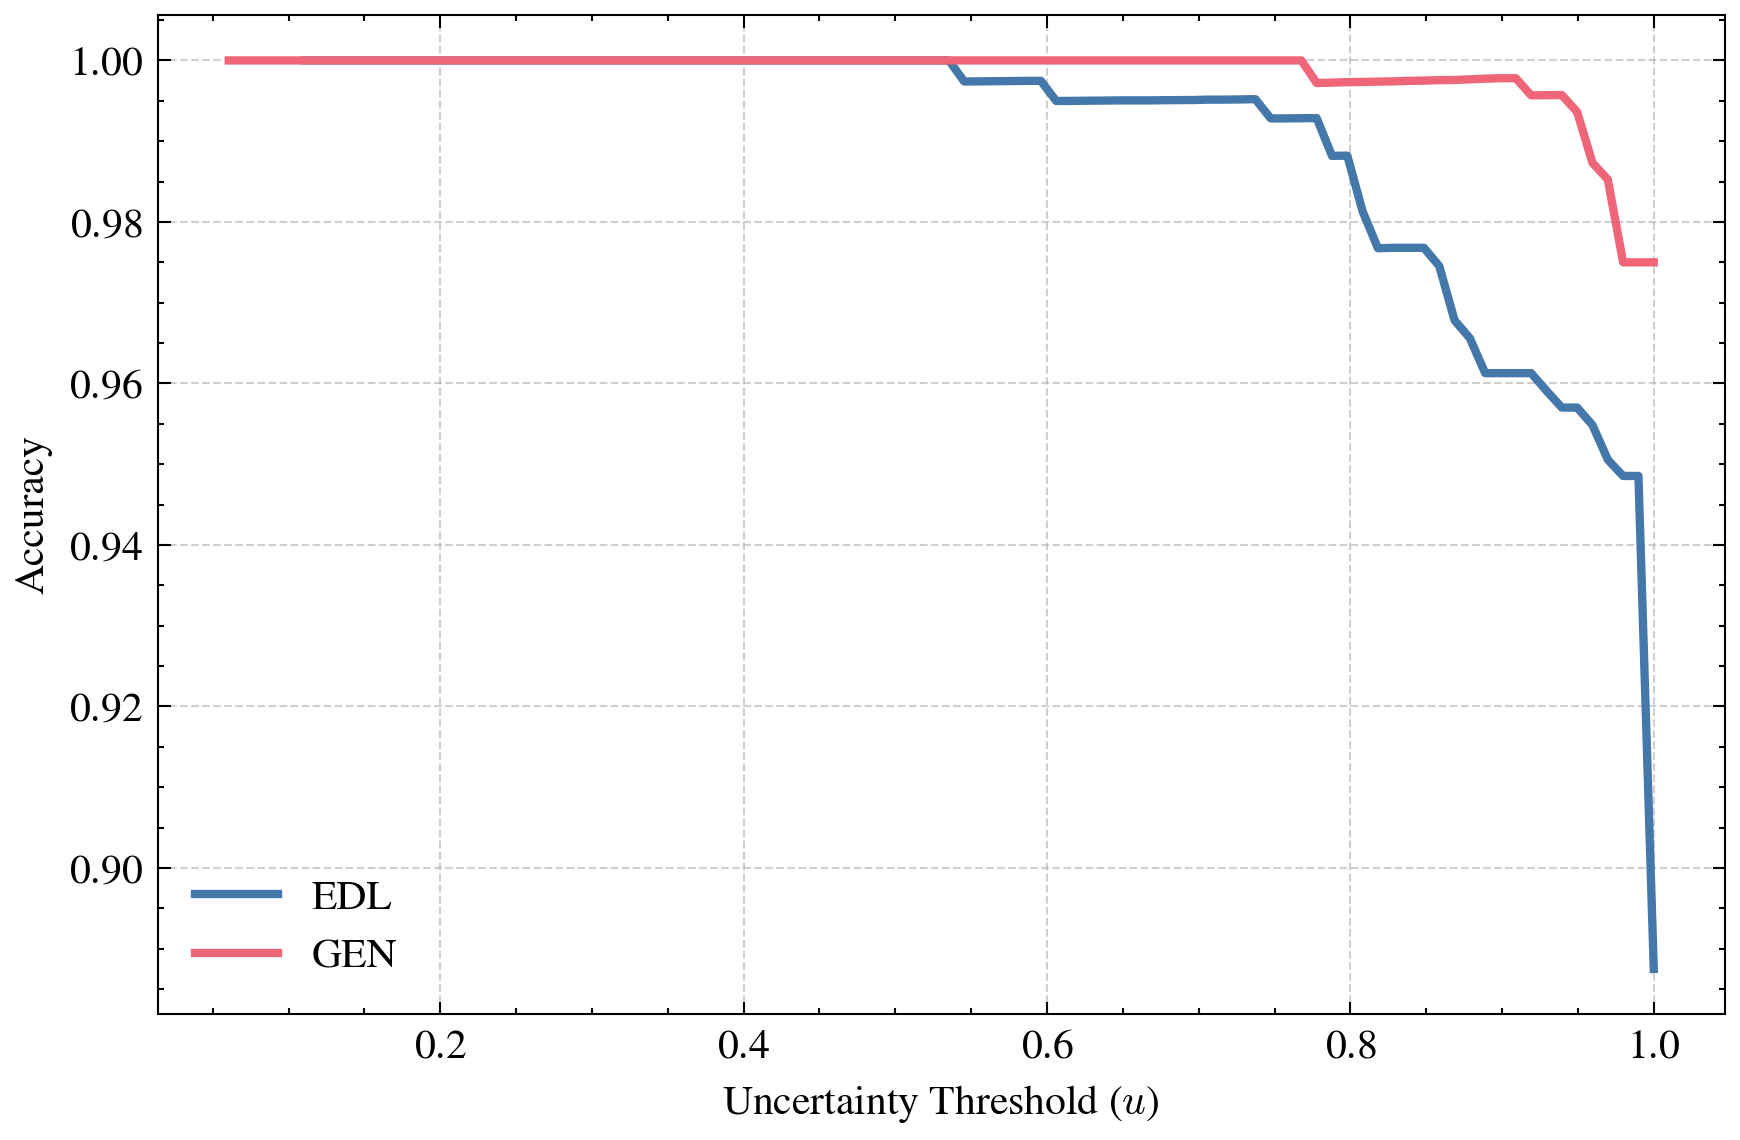

In [ ]:
def accuracy_vs_uncertainty(
    model: torch.nn.Module,
    inference_fn: Callable,
    dataloader: torch.utils.data.DataLoader,
    device: torch.device,
) -> tuple[np.ndarray, list[float]]:
    """Compute accuracy vs uncertainty curve for the given model and dataloader.

    Arguments:
        model (torch.nn.Module): The trained model to evaluate.
        inference_fn (Callable): A function that takes the model's logits and returns predictions and uncertainties.
        dataloader (torch.utils.data.DataLoader): DataLoader for the dataset to evaluate on.
        device (torch.device): The device to run the model on.

    Returns:
        tuple: A tuple containing:
            - np.ndarray: Array of uncertainty thresholds.
            - list[float]: List of accuracies corresponding to each uncertainty threshold.

    """
    model.eval()
    all_uncertainties = []
    all_correct = []

    with torch.no_grad():
        for x, y in dataloader:
            with torch.autocast(device_type=device.type, dtype=torch.float16):
                logits = model(x.to(device))

            # Using your edl_inference function
            pred, uncertainty, _ = inference_fn(logits)

            correct = (pred == y.to(device)).cpu().numpy()
            all_correct.extend(correct)
            all_uncertainties.extend(uncertainty.cpu().numpy())

    all_correct = np.array(all_correct)
    all_uncertainties = np.array(all_uncertainties)

    # Define thresholds (from 0.0 to 1.0)
    thresholds = np.linspace(0, 1, 100)
    accuracies = []

    for t in thresholds:
        mask = all_uncertainties <= t
        if np.any(mask):
            acc = np.mean(all_correct[mask])
            accuracies.append(acc)
        else:
            accuracies.append(None)

    return thresholds, accuracies


# Collect data
edl_thresholds, edl_accuracies = accuracy_vs_uncertainty(edl_fusion, edl_inference, test_dl, DEVICE)
gen_thresholds, gen_accuracies = accuracy_vs_uncertainty(gen_fusion, gen_inference, test_dl, DEVICE)

plt.figure(figsize=(6, 4))

# Accuracy Curve
plt.plot(edl_thresholds, edl_accuracies, lw=2, label="EDL")
plt.plot(gen_thresholds, gen_accuracies, lw=2, label="GEN")

plt.xlabel("Uncertainty Threshold ($u$)")
plt.ylabel("Accuracy")
plt.tick_params(axis="y")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "edl_accuracy_vs_uncertainty.pdf")
plt.show()

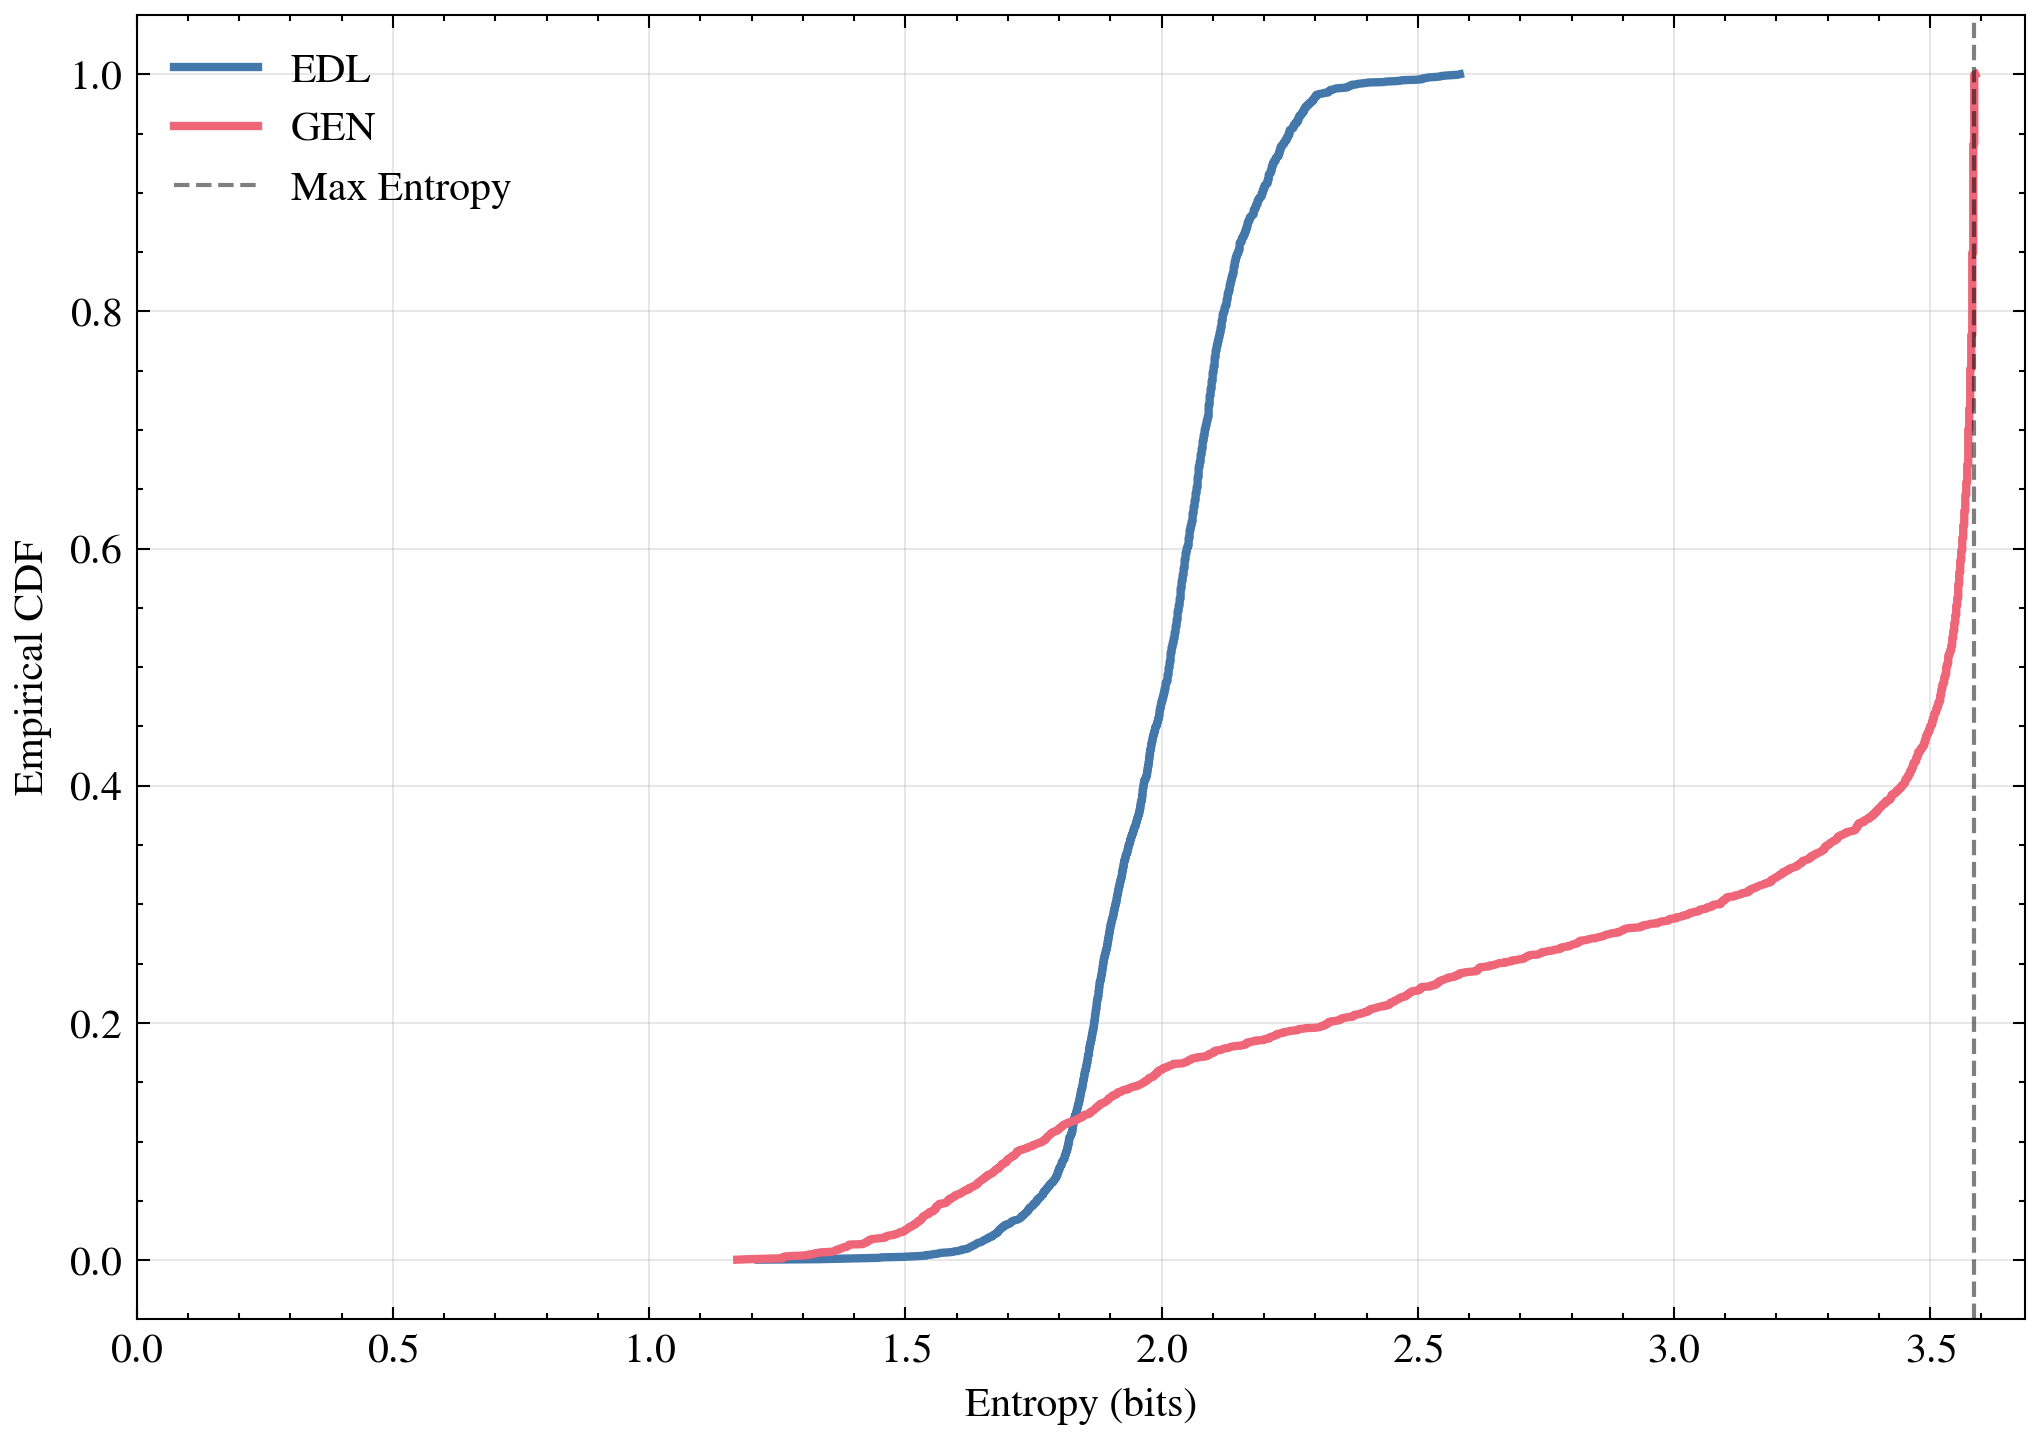

In [ ]:
def compute_ood_entropy(
    model: torch.nn.Module,
    inference_fn: Callable,
    ood_loader: torch.utils.data.DataLoader,
    device: torch.device,
) -> np.ndarray:
    """Compute the entropy of the model's predictions on OOD samples.

    Arguments:
        model (torch.nn.Module): The trained model to evaluate.
        inference_fn (Callable): A function that takes the model's logits
            and returns predictions, uncertainties, and p_hat values.
        ood_loader (torch.utils.data.DataLoader): DataLoader for the OOD dataset to evaluate on.
        device (torch.device): The device to run the model

    Returns:
        np.ndarray: An array of entropy values for each OOD sample.

    """
    model.eval()
    entropies = []

    with torch.no_grad():
        for x, _ in ood_loader:
            with torch.autocast(device_type=device.type, dtype=torch.float16):
                logits = model(x.to(device))

            # 1. Get Dirichlet probabilities (p = alpha / S)
            # Ensure your model/inference applies softplus/relu for evidence
            _, _, probs = inference_fn(logits)

            # 2. Compute Entropy: -sum(p * log(p))
            # Add epsilon to avoid log(0)
            eps = 1e-10
            entropy = -torch.sum(probs * torch.log2(probs + eps), dim=1)
            entropies.extend(entropy.cpu().numpy())

    return np.array(entropies)


# Collect entropies for both models
results = {
    "EDL": compute_ood_entropy(edl_fusion, edl_inference, ood_dl, DEVICE),
    "GEN": compute_ood_entropy(gen_fusion, gen_inference, ood_dl, DEVICE),
}
max_entropy = np.log2(settings.n_activities)

plt.figure(figsize=(7, 5))

for label, entropies in results.items():
    # Sort data for ECDF
    x = np.sort(entropies)
    y = np.arange(1, len(x) + 1) / len(x)

    plt.plot(x, y, label=label, lw=2)

plt.axvline(x=max_entropy, color="k", linestyle="--", alpha=0.5, label="Max Entropy")

plt.xlabel("Entropy (bits)")
plt.ylabel("Empirical CDF")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, max_entropy + 0.1)
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "edl_ood_entropy_cdf.pdf")
plt.show()

## Decision Tree Classifier

In [ ]:
def extract_vae_features(
    gaussians: list[vae.SingleAntenna],
    dataloader: torch.utils.data.DataLoader,
    device: torch.device,
) -> tuple[np.ndarray, np.ndarray]:
    """Extract latent features (mu and logvar) from each antenna's Gaussian encoder for the given dataloader.

    Arguments:
        gaussians (list[vae.SingleAntenna]): List of Gaussian encoders, one per antenna.
        dataloader (torch.utils.data.DataLoader): DataLoader for the dataset to extract features from.
        device (torch.device): The device to perform computations on (e.g., CPU or GPU).

    Returns:
        tuple: A tuple containing:
            - features: A NumPy array of shape (num_samples, num_antennas * 2 * n_gaussians)
                with the concatenated mu and logvar features from all antennas.
            - labels: A NumPy array of shape (num_samples,) with the corresponding activity labels for each sample.

    """
    features = []
    labels = []

    with torch.no_grad():
        for x, y in dataloader:
            # Replicate the logic in your Delayed.forward:
            # Extract mu and logvar from each antenna
            outs = []
            for i, antenna in enumerate(gaussians):
                antenna.eval()

                with torch.autocast(device_type=DEVICE.type, dtype=torch.float16):
                    _, mu, logvar = antenna(x[:, i].to(device))
                outs.append(torch.cat([mu, logvar], dim=1))

            z = torch.cat(outs, dim=1)
            features.append(z.cpu().numpy())
            labels.append(y.numpy())

    return np.concatenate(features), np.concatenate(labels)


feat_names = []
for ant_idx in range(settings.n_antennas):
    # First half for this antenna is mu
    feat_names.extend([f"$\\mu_{ant_idx}^{g_idx}$" for g_idx in range(settings.n_gaussians)])
    # Second half for this antenna is sigma
    feat_names.extend([f"$\\log\\sigma_{ant_idx}^{g_idx}$" for g_idx in range(settings.n_gaussians)])

# Prepare data
X_train, y_train = extract_vae_features(gaussians, train_dl, DEVICE)
X_test, y_test = extract_vae_features(gaussians, test_dl, DEVICE)

In [ ]:
# Initialize and train the Tree
# We limit max_depth so the visualization is actually readable
tree_clf = DecisionTreeClassifier(max_depth=4, criterion="entropy", random_state=best_model.seed)
tree_clf.fit(X_train, y_train)

print(f"Decision Tree Accuracy: {tree_clf.score(X_test, y_test):.4f}")

Decision Tree Accuracy: 0.8562


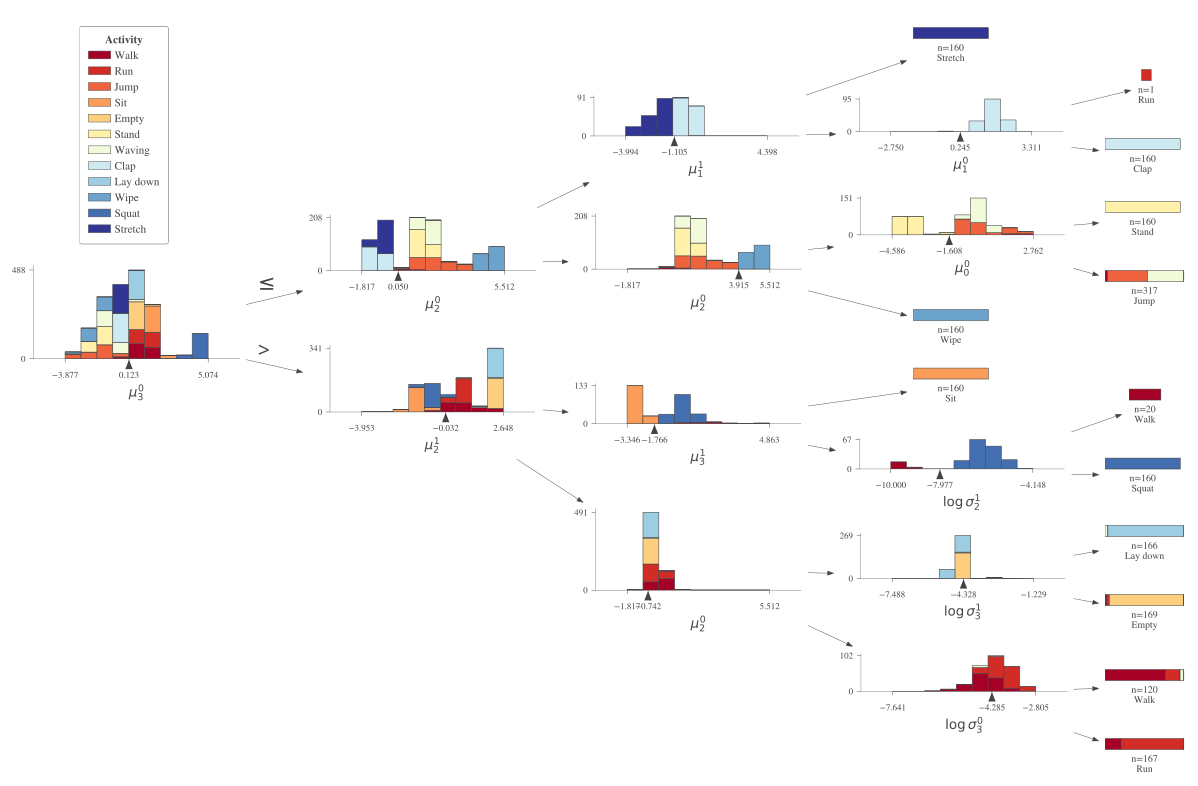

In [ ]:
plt.style.use("default") # Revert back to default style for dtreeviz

viz = dtreeviz.model(
    tree_clf,
    X_train=X_train,
    y_train=y_train,
    feature_names=feat_names,
    target_name="Activity",
    class_names=ACTIVITIES,
)

v = viz.view(scale=1.5, leaftype="barh", orientation="LR", fontname="STIXGeneral")
v.save(str(PLOTS_DIR / "latent_logic_tree.svg"))
v